# Role 3: Modeling & Evaluation Lead
**Dataset:** Credit Card Default (Taiwan)

This notebook handles the implementation, tuning, and evaluation of three classification models: Logistic Regression (Baseline), Decision Tree, and K-Nearest Neighbors. It relies on the preprocessed, scaled, and SMOTE-balanced data generated by `preprocessing.ipynb`.

## 1. Imports & Setup
Importing necessary libraries for model building, metric calculation, and visualization.

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# scikit-learn models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# scikit-learn evaluation metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

## 2. Load Processed Data
Loading the train, validation, and test splits exported from the preprocessing pipeline. The training set (`X_train_balanced`) has already been scaled and balanced using SMOTE.

In [2]:
# Load the splits into memory using relative paths
with open('../data/processed_splits.pkl', 'rb') as f:
    X_train_balanced, X_val, X_test, y_train_balanced, y_val, y_test = pickle.load(f)

# Extract column names for later feature importance mapping
# (Assuming the original feature names are preserved; adjust if your teammate saved them differently)
feature_names = [
    'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

print(f"✓ Data successfully imported!")
print(f"Training shape: {X_train_balanced.shape}, Validation shape: {X_val.shape}")

✓ Data successfully imported!
Training shape: (29906, 23), Validation shape: (4800, 23)


## 3. Model 1: Logistic Regression (Baseline)
We establish our baseline using a linear model to test if the balanced classes are linearly separable.

In [3]:
# Initialize and train the baseline model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_balanced, y_train_balanced)

# Generate predictions on the validation set
y_val_pred_lr = log_reg.predict(X_val)
y_val_prob_lr = log_reg.predict_proba(X_val)[:, 1]

# Calculate validation metrics
acc_lr = accuracy_score(y_val, y_val_pred_lr)
f1_lr = f1_score(y_val, y_val_pred_lr)
auc_lr = roc_auc_score(y_val, y_val_prob_lr)

print("--- Logistic Regression Validation Results ---")
print(f"Accuracy:  {acc_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print(f"AUC Score: {auc_lr:.4f}")

--- Logistic Regression Validation Results ---
Accuracy:  0.6890
F1-Score:  0.4723
AUC Score: 0.7209


## 4. Model 2: Decision Tree
Next, we implement a Decision Tree to capture non-linear relationships and extract specific feature importances. We restrict `max_depth` to 5 to prevent overfitting to the training data.

--- Decision Tree Validation Results ---
Accuracy:  0.7515
F1-Score:  0.5172
AUC Score: 0.7487



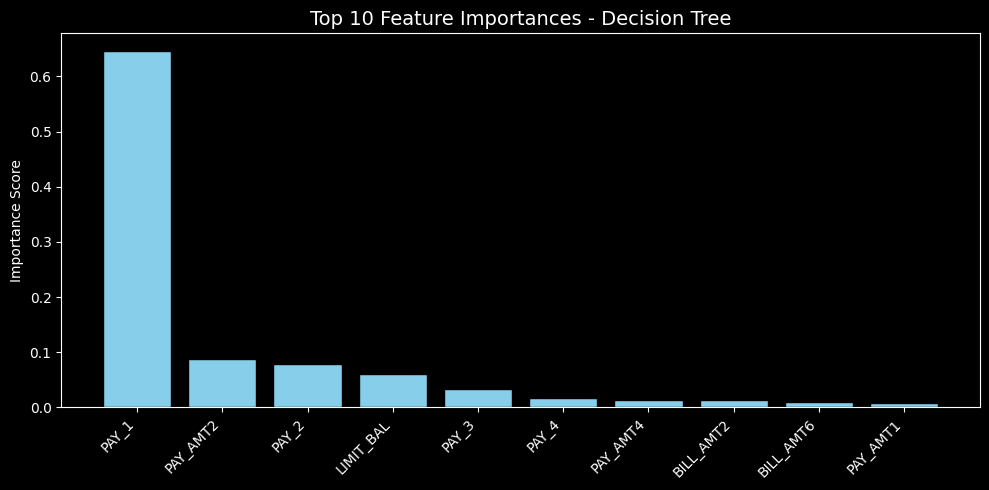

In [4]:
# Initialize and train the Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_balanced, y_train_balanced)

# Generate predictions on the validation set
y_val_pred_dt = dt_model.predict(X_val)
y_val_prob_dt = dt_model.predict_proba(X_val)[:, 1]

# Calculate validation metrics
acc_dt = accuracy_score(y_val, y_val_pred_dt)
f1_dt = f1_score(y_val, y_val_pred_dt)
auc_dt = roc_auc_score(y_val, y_val_prob_dt)

print("--- Decision Tree Validation Results ---")
print(f"Accuracy:  {acc_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")
print(f"AUC Score: {auc_dt:.4f}\n")

# Plot Top 10 Feature Importances
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Top 10 Feature Importances - Decision Tree", fontsize=14)
plt.bar(range(10), importances[indices][:10], align="center", color='skyblue', edgecolor='black')
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45, ha='right')
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

## 5. Model 3: K-Nearest Neighbors (KNN)
Finally, we test a distance-based algorithm. KNN is well-suited here because the numerical features were scaled using `StandardScaler` during preprocessing.

In [5]:
# Initialize and train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_balanced, y_train_balanced)

# Generate predictions on the validation set
y_val_pred_knn = knn_model.predict(X_val)
y_val_prob_knn = knn_model.predict_proba(X_val)[:, 1]

# Calculate validation metrics
acc_knn = accuracy_score(y_val, y_val_pred_knn)
f1_knn = f1_score(y_val, y_val_pred_knn)
auc_knn = roc_auc_score(y_val, y_val_prob_knn)

print("--- K-Nearest Neighbors Validation Results ---")
print(f"Accuracy:  {acc_knn:.4f}")
print(f"F1-Score:  {f1_knn:.4f}")
print(f"AUC Score: {auc_knn:.4f}")

--- K-Nearest Neighbors Validation Results ---
Accuracy:  0.6646
F1-Score:  0.4417
AUC Score: 0.6790


## 6. Validation Set Model Comparison
We aggregate the performance of all three models on the unseen validation set to select the strongest candidate for final testing.

In [6]:
# Create a summary DataFrame
results_dict = {
    "Model": ["Logistic Regression", "Decision Tree", "K-Nearest Neighbors"],
    "Accuracy": [acc_lr, acc_dt, acc_knn],
    "F1-Score": [f1_lr, f1_dt, f1_knn],
    "AUC Score": [auc_lr, auc_dt, auc_knn]
}

results_df = pd.DataFrame(results_dict).round(4)

print("--- Validation Performance Summary ---")
display(results_df)

--- Validation Performance Summary ---


,Model,Accuracy,F1-Score,AUC Score
0,Logistic Regression,0.6890,0.4723,0.7209
1,Decision Tree,0.7515,0.5172,0.7487
2,K-Nearest Neighbors,0.6646,0.4417,0.6790


## 7. Final Test Evaluation & Error Analysis
The Decision Tree demonstrated the highest AUC and F1-Score on the validation set. We now run this winning model exactly **once** on the held-out test set to determine our final, unbiased performance metrics.

 FINAL UNSEEN TEST SET RESULTS (Decision Tree)
Final Test Accuracy:  0.7430
Final Test F1-Score:  0.4964
Final Test AUC:       0.7421



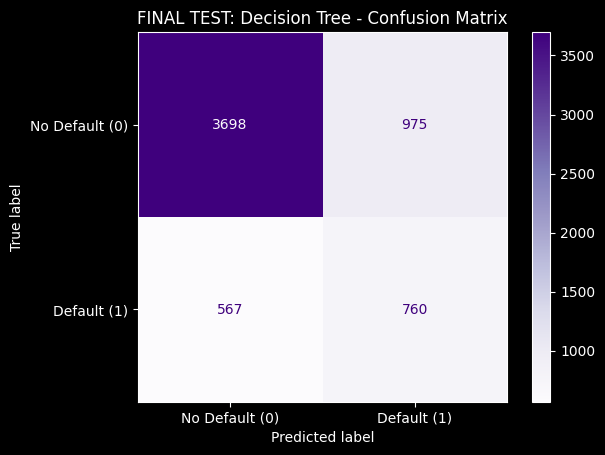

In [7]:
# Generate predictions on the untouched Test Set
y_test_pred = dt_model.predict(X_test)
y_test_prob = dt_model.predict_proba(X_test)[:, 1]

# Calculate final test metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("======================================================")
print(" FINAL UNSEEN TEST SET RESULTS (Decision Tree)")
print("======================================================")
print(f"Final Test Accuracy:  {test_acc:.4f}")
print(f"Final Test F1-Score:  {test_f1:.4f}")
print(f"Final Test AUC:       {test_auc:.4f}\n")

# Generate the Final Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['No Default (0)', 'Default (1)'])
disp_test.plot(cmap='Purples')
plt.title("FINAL TEST: Decision Tree - Confusion Matrix")
plt.show()